In [1]:
# -*- coding: utf-8 -*-
"""MNIST_ViT_PyTorch.ipynb"""

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt


# =========================
# デバイス設定
# =========================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


# =========================
# データの読み込みと前処理
# =========================

transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),   # [0, 1] に正規化し、shape は (1, 28, 28)
])

train_dataset_full = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# 計算時間がかかるので、感触を掴む段階においては、リストの後ろからN個の要素を削除
# 60_000がデフォルト
# x_train = x_train[:-50_000] に対応
#train_dataset = Subset(train_dataset_full, range(len(train_dataset_full) - 50_000))

train_dataset = Subset(train_dataset_full, range(len(train_dataset_full)))

batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


# =========================
# ViT のパラメータ
# =========================

image_size = 28         # 画像の高さ/幅
patch_size = 4          # パッチサイズ
num_patches = (image_size // patch_size) ** 2  # パッチ数
projection_dim = patch_size * patch_size     # 埋め込みの次元
num_heads = 2           # マルチヘッドアテンションのヘッド数
transformer_layers = 2  # Transformer ブロック数


# projection_dim = 埋め込み次元・特徴次元（固定されるパラメタ）
# num_patches = シーケンス長（アテンション機構としては
#                             可変長になり得るものだが、ここでは固定）


# =========================
# 固定2次元位置エンコーディング
# =========================

def positional_encoding_2d(H, W, d):
    assert d % 4 == 0
    d_quarter = d // 4

    y = np.arange(H)[:, None]        # (H, 1)
    x = np.arange(W)[None, :]        # (1, W)

    div_term = np.exp(
        -np.log(10000.0) * np.arange(d_quarter) / d_quarter
    )  # (d_quarter,)

    # 次元を合わせる（これが核心）
    y = y[:, :, None]                   # (H, 1, 1)
    x = x[:, :, None]                   # (1, W, 1)
    div_term = div_term[None, None, :]  # (1, 1, d_quarter)

    pe = np.zeros((H, W, d))

    # y方向
    pe[:, :, 0:d//2:2] = np.sin(y * div_term)
    pe[:, :, 1:d//2:2] = np.cos(y * div_term)

    # x方向
    pe[:, :, d//2::2] = np.sin(x * div_term)
    pe[:, :, d//2+1::2] = np.cos(x * div_term)

    return pe.reshape(H * W, d)


# =========================
# Self-Attention Block
# =========================

class SelfAttentionBlock(nn.Module):
    def __init__(self, num_heads, projection_dim):
        super().__init__()

        self.attention = nn.MultiheadAttention(
            embed_dim=projection_dim,
            num_heads=num_heads,
            batch_first=True
        )

    def forward(self, x):
        # 第1引数 → Query
        # 第2引数 → Key
        # 第3引数 → Value
        # 自己注意なので、同じ引数になる

        attention_output, attention_weights = self.attention(x, x, x)

        # PyTorch の MultiheadAttention も、
        # 内部で各ヘッドをconcatした後、線形層で embed_dim に戻している
        # したがって出力のshapeは入力と同じ：
        # (batch_size, num_patches, projection_dim)

        x1 = x + attention_output  # 残差接続（ただ足してるだけ）

        return x1


# =========================
# ViT Model
# =========================

class SimpleViT(nn.Module):
    def __init__(self, input_channels, num_classes):
        super().__init__()

        # パッチ分割
        self.patch_embedding = nn.Unfold(
            kernel_size=patch_size,
            stride=patch_size,
            padding=0
        )

        H = W = image_size // patch_size
        position_embedding = positional_encoding_2d(H, W, projection_dim)

        # 学習しない固定位置エンコーディングとして登録
        self.register_buffer(
            "position_embedding",
            torch.tensor(position_embedding, dtype=torch.float32).unsqueeze(0)
        )

        # shape: (1, num_patches, projection_dim)
        self.transformer_blocks = nn.ModuleList([
            SelfAttentionBlock(num_heads, projection_dim)
            for _ in range(transformer_layers)
        ])

        self.flatten = nn.Flatten()

        self.classifier = nn.Linear(
            num_patches * projection_dim,
            num_classes
        )

    def forward(self, inputs):

        # inputs shape:
        # PyTorch:    (batch, 1, 28, 28)

        patches = self.patch_embedding(inputs)
        # shape: (batch, projection_dim, H, W)

        # (batch, projection_dim, H, W)
        # から
        # (batch, num_patches, projection_dim)
        # に変換する
        patches = patches.transpose(1, 2)


        # 固定位置エンコーディングを加える
        x = patches + self.position_embedding

        # Transformer Encoder を適用
        # 同じ構造のブロックを層の数だけ繰り返す
        # 学習可能パラメタはブロックごとに別々
        for block in self.transformer_blocks:
            x = block(x)

        x = self.flatten(x)

        outputs = self.classifier(x)

        return outputs


# =========================
# モデルの作成
# =========================

model = SimpleViT(input_channels=1, num_classes=10).to(device)

print(model)


# =========================
# モデルのコンパイル相当
# =========================

optimizer = torch.optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss()

device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 12.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 336kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.16MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.48MB/s]


SimpleViT(
  (patch_embedding): Unfold(kernel_size=4, dilation=1, padding=0, stride=4)
  (transformer_blocks): ModuleList(
    (0-1): 2 x SelfAttentionBlock(
      (attention): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=16, out_features=16, bias=True)
      )
    )
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (classifier): Linear(in_features=784, out_features=10, bias=True)
)


In [2]:
%%time

# =========================
# モデルの学習
# =========================

epochs = 30

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
}

for epoch in range(epochs):
    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_accuracy = train_correct / train_total

    # validation
    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_accuracy = val_correct / val_total

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train loss: {train_loss:.4f}, "
        f"Train accuracy: {train_accuracy:.4f}, "
        f"Val loss: {val_loss:.4f}, "
        f"Val accuracy: {val_accuracy:.4f}"
    )


# =========================
# モデルの評価
# =========================

model.eval()

test_loss = 0.0
test_correct = 0
test_total = 0

all_predictions = []
all_images = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)

        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)

        all_predictions.append(outputs.cpu())
        all_images.append(images.cpu())
        all_labels.append(labels.cpu())

test_loss /= test_total
test_accuracy = test_correct / test_total

print("\nTest loss:", test_loss)
print("Test accuracy:", test_accuracy)

predictions = torch.cat(all_predictions, dim=0).numpy()
x_test = torch.cat(all_images, dim=0).numpy()
y_test = torch.cat(all_labels, dim=0).numpy()

Epoch [1/30] Train loss: 0.6000, Train accuracy: 0.8377, Val loss: 0.2886, Val accuracy: 0.9156
Epoch [2/30] Train loss: 0.2767, Train accuracy: 0.9176, Val loss: 0.2437, Val accuracy: 0.9290
Epoch [3/30] Train loss: 0.2434, Train accuracy: 0.9274, Val loss: 0.2263, Val accuracy: 0.9332
Epoch [4/30] Train loss: 0.2237, Train accuracy: 0.9333, Val loss: 0.2142, Val accuracy: 0.9371
Epoch [5/30] Train loss: 0.2108, Train accuracy: 0.9369, Val loss: 0.2081, Val accuracy: 0.9367
Epoch [6/30] Train loss: 0.2019, Train accuracy: 0.9400, Val loss: 0.1912, Val accuracy: 0.9424
Epoch [7/30] Train loss: 0.1926, Train accuracy: 0.9425, Val loss: 0.1868, Val accuracy: 0.9445
Epoch [8/30] Train loss: 0.1832, Train accuracy: 0.9453, Val loss: 0.1809, Val accuracy: 0.9470
Epoch [9/30] Train loss: 0.1773, Train accuracy: 0.9472, Val loss: 0.1848, Val accuracy: 0.9425
Epoch [10/30] Train loss: 0.1700, Train accuracy: 0.9493, Val loss: 0.1675, Val accuracy: 0.9496
Epoch [11/30] Train loss: 0.1630, Train

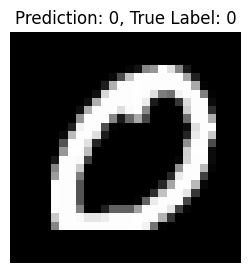

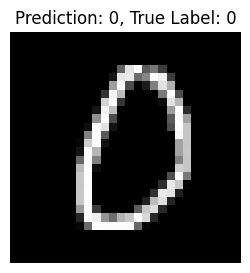

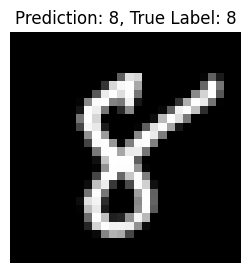

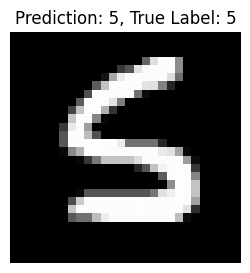

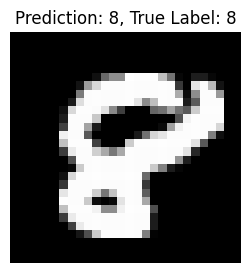

In [3]:

# =========================
# 予測結果の可視化
# =========================

num_images_to_show = 5
random_indices = np.random.choice(len(x_test), size=num_images_to_show, replace=False)

for i in random_indices:
    plt.figure(figsize=(3, 3))

    # PyTorchの画像shapeは (1, 28, 28)
    # 表示用に (28, 28) にする
    plt.imshow(x_test[i].squeeze(), cmap="gray")

    plt.title(
        f"Prediction: {np.argmax(predictions[i])}, "
        f"True Label: {y_test[i]}"
    )

    plt.axis("off")
    plt.show()